# Sparse PCA — warm-started from artificial patterns

Start from a loading pattern the desk *thinks* a factor should look
like (a 2s10s steepener mask, a butterfly, a short-end shock, …) and
let `factors.sparse_pca_warm` refine it against the actual cube. The
iteration has two opposing terms:

* a **data-fit** term that pulls loadings toward the top-variance
  direction of the panel (regular PCA);
* an **anchor** term `||w − w_prior||²` that pulls them back to the
  prior.

`anchor` is scaled by N internally so it's on a unit scale: `0` is
unconstrained PCA with a warm start, `~1` is balanced, `~10` is
essentially frozen. Optional `l1` adds explicit sparsification.

All analysis is on **daily diffs** of the wide panel — we hedge
moves, not levels.

## 0. Setup

In [ ]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pca import load_long, to_wide, EXPIRY_LABELS, TENOR_LABELS
from factors import (
    sparse_pca_warm, loading_sparsity,
    soft_constrained_pca, lambda_search,
)

sns.set_theme(style="whitegrid")

rate = to_wide(load_long("../data/mock/rate.pkl")).diff().dropna()
print("rate diff:", rate.shape)

def loading_heatmap(ax, w_vec, title, vmax, cbar=False):
    series = pd.Series(w_vec, index=rate.columns)
    grid = series.unstack("tenor").reindex(
        index=[e for e in EXPIRY_LABELS if e in rate.columns.get_level_values("expiry")],
        columns=[t for t in TENOR_LABELS if t in rate.columns.get_level_values("tenor")],
    )
    sns.heatmap(grid, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax, cbar=cbar)
    ax.set_title(title); ax.set_xlabel("Tenor"); ax.set_ylabel("Expiry")

rate diff: (499, 204)


## 1. Artificial pattern — 2s10s steepener

Across all expiries, weight the 2Y tenor at `−1` and the 10Y tenor at
`+1`. Everything else is zero. This is the canonical curve-steepener
mask — what a trader would write down before looking at any data.

In [ ]:
prior_2s10s = pd.Series(0.0, index=rate.columns, name="2s10s")
prior_2s10s[prior_2s10s.index.get_level_values("tenor") == "2Y"]  = -1.0
prior_2s10s[prior_2s10s.index.get_level_values("tenor") == "10Y"] = +1.0
prior_norm = prior_2s10s.values / np.linalg.norm(prior_2s10s.values)
print(f"prior nonzero cells: {(prior_2s10s != 0).sum()} / {len(prior_2s10s)}")

prior nonzero cells: 34 / 204


## 2. Anchor sweep — fit vs. prior similarity

Run `sparse_pca_warm` across a range of anchor weights. As anchor
rises, loadings move from the unconstrained top eigenvector
(`anchor=0`, cosine ≈ 0 with the prior) toward the prior itself
(`anchor≈20`, cosine ≈ 1). The variance share drops smoothly across
the trade-off.

In [ ]:
anchors = [0.0, 0.5, 2.0, 5.0, 20.0]
fits = {a: sparse_pca_warm(rate, prior_2s10s, anchor=a) for a in anchors}

rows = []
for a, (s, l, e) in fits.items():
    w = l.iloc[0].values
    rows.append({
        "anchor":         a,
        "var_explained":  float(e.iloc[0]),
        "||w - prior||":  float(np.linalg.norm(w - prior_norm)),
        "cos(w, prior)":  float(w @ prior_norm),
        "loading_gini":   float(loading_sparsity(l).iloc[0]),
    })
trade = pd.DataFrame(rows)
print(trade.round(4).to_string(index=False))

 anchor  var_explained  ||w - prior||  cos(w, prior)  loading_gini
    0.0         0.0393         1.4131         0.0015        0.1534
    0.5         0.0391         1.3617         0.0729        0.1599
    2.0         0.0365         1.1943         0.2869        0.2278
    5.0         0.0219         0.7566         0.7138        0.2918
   20.0         0.0048         0.0397         0.9992        0.7993


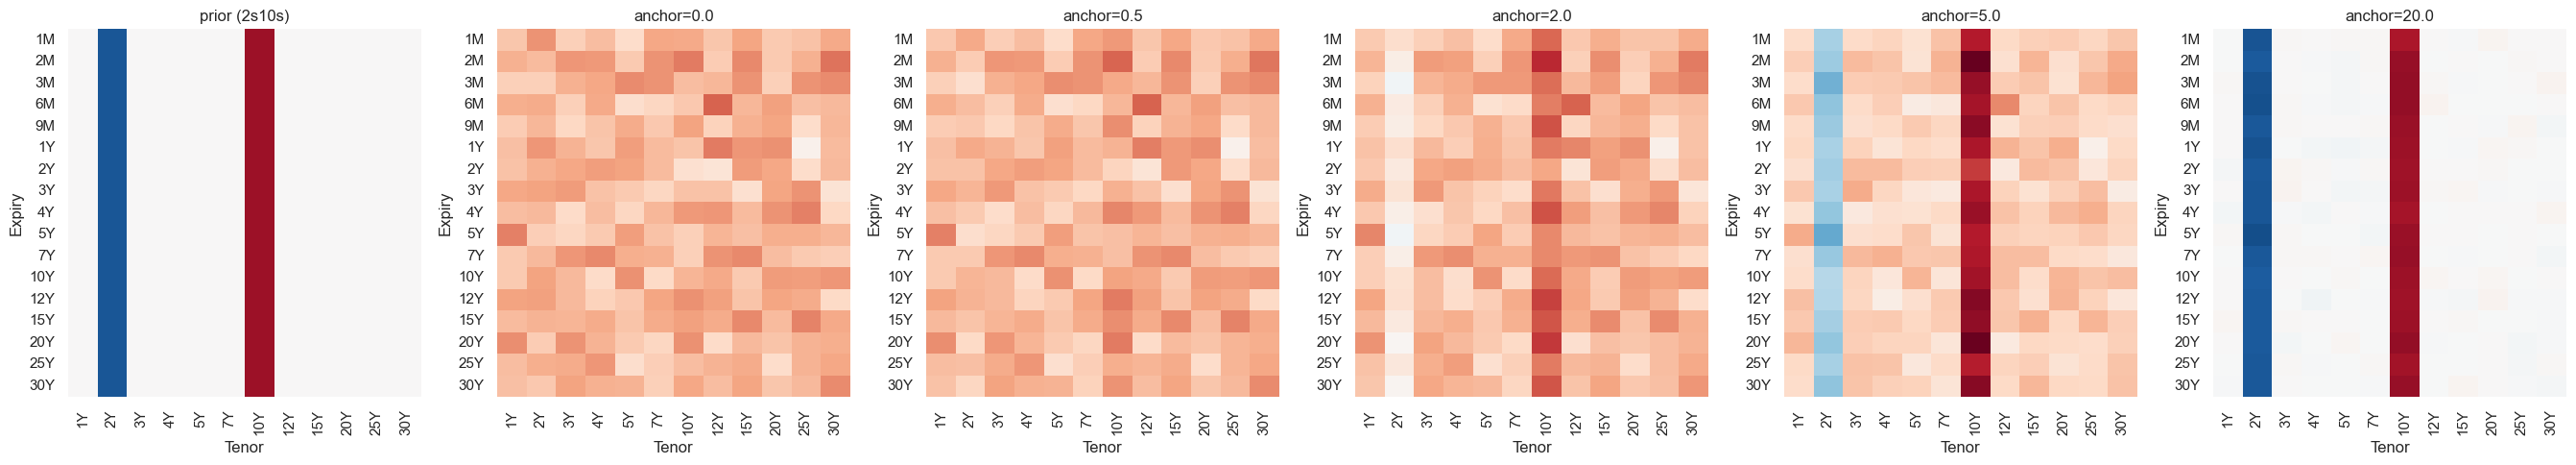

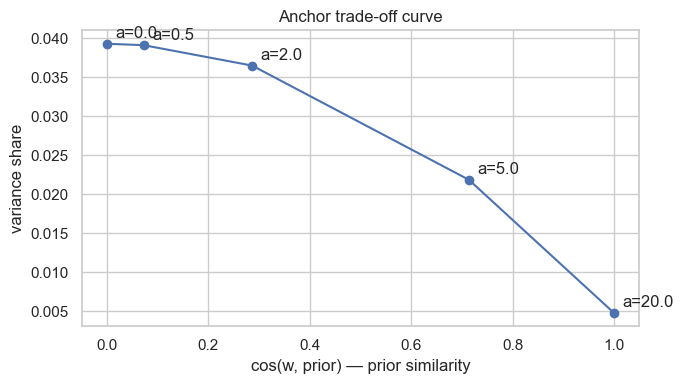

In [ ]:
# Loading heatmaps: prior + each anchored fit.
panels = [("prior (2s10s)", prior_norm)]
for a in anchors:
    panels.append((f"anchor={a}", fits[a][1].iloc[0].values))

vmax = max(float(np.abs(v).max()) for _, v in panels)
fig, axes = plt.subplots(1, len(panels), figsize=(4.5 * len(panels), 5))
for ax, (title, w) in zip(axes, panels):
    loading_heatmap(ax, w, title, vmax)
plt.tight_layout(); plt.show()

# Trade-off curve.
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(trade["cos(w, prior)"], trade["var_explained"], marker="o")
for _, r in trade.iterrows():
    ax.annotate(f"a={r['anchor']}", (r["cos(w, prior)"], r["var_explained"]),
                textcoords="offset points", xytext=(6, 4))
ax.set_xlabel("cos(w, prior) — prior similarity")
ax.set_ylabel("variance share")
ax.set_title("Anchor trade-off curve")
plt.tight_layout(); plt.show()

## 3. Adding L1 — explicit sparsification

At a fixed `anchor`, sweep `l1` to soft-threshold the loading entries.
`l1` is N-scaled so values in `[0, ~1]` are meaningful. Larger `l1`
kills more cells; the prior region (2Y, 10Y stripes) survives longest.

  l1  var_explained  nonzero(>1e-3)  loading_gini  cos(w, prior)
0.00         0.0386             204        0.1766         0.1442
0.05         0.0384             204        0.1994         0.1610
0.20         0.0360             195        0.3322         0.2464
0.50         0.0000               0        0.0000         0.0000


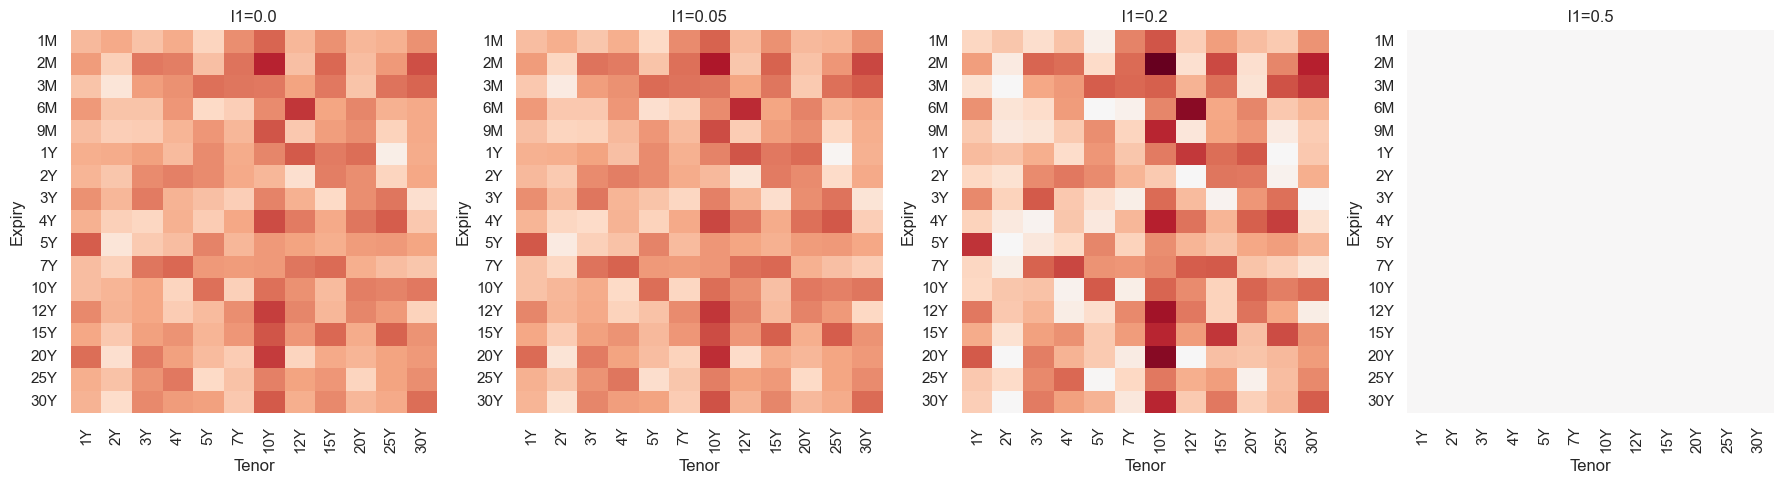

In [ ]:
l1_values = [0.0, 0.05, 0.2, 0.5]
l1_fits = {l1: sparse_pca_warm(rate, prior_2s10s, anchor=1.0, l1=l1) for l1 in l1_values}

rows = []
for l1, (s, l, e) in l1_fits.items():
    w = l.iloc[0].values
    rows.append({
        "l1":            l1,
        "var_explained": float(e.iloc[0]),
        "nonzero(>1e-3)": int((np.abs(w) > 1e-3).sum()),
        "loading_gini":  float(loading_sparsity(l).iloc[0]),
        "cos(w, prior)": float(w @ prior_norm),
    })
print(pd.DataFrame(rows).round(4).to_string(index=False))

panels = [(f"l1={l1}", l1_fits[l1][1].iloc[0].values) for l1 in l1_values]
vmax = max(float(np.abs(v).max()) for _, v in panels)
fig, axes = plt.subplots(1, len(panels), figsize=(4.5 * len(panels), 5))
for ax, (title, w) in zip(axes, panels):
    loading_heatmap(ax, w, title, vmax)
plt.tight_layout(); plt.show()

## 4. Multiple priors — steepener + butterfly

Pass a multi-row prior to fit several anchored factors in one call.
Each row becomes one initialised factor; the algorithm deflates the
panel between factors. Useful when the desk has a small basis of
hand-drawn patterns and wants the data-refined version of each.

variance share per anchored factor:
2s10s           0.0365
5y_butterfly    0.0098
Name: explained_variance_ratio, dtype: float64


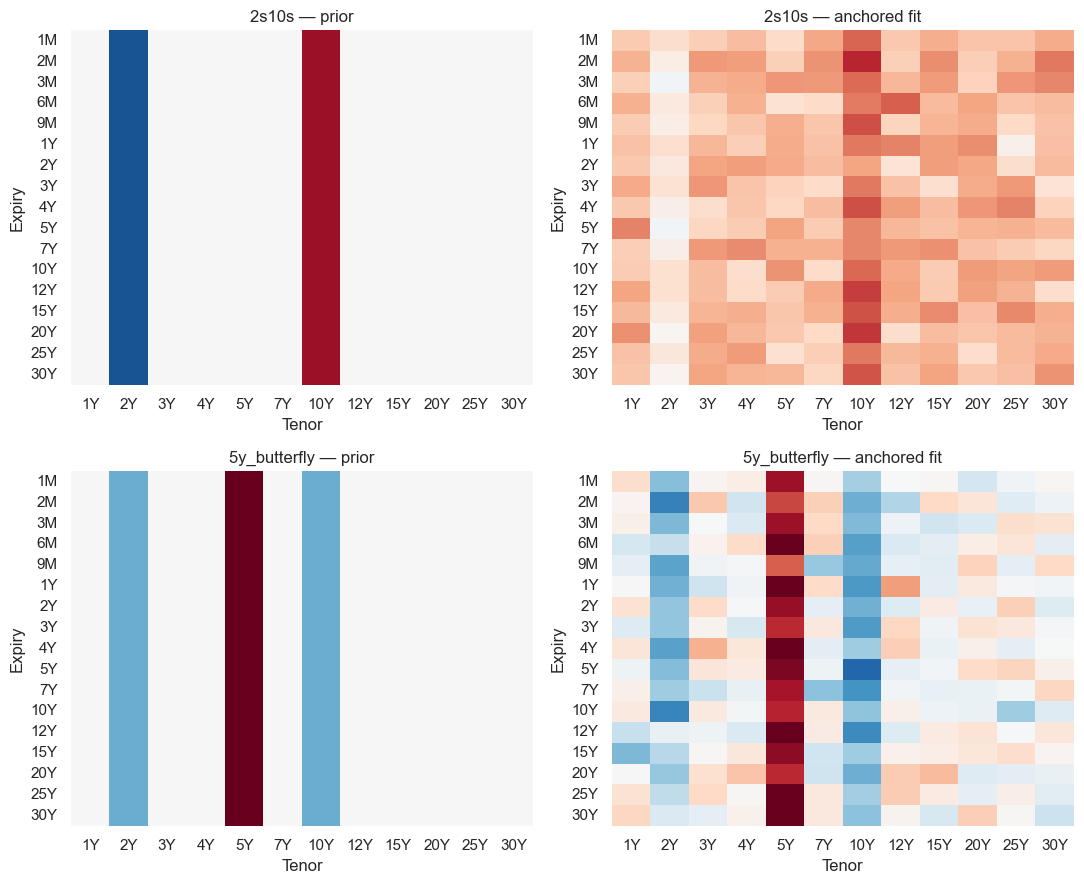

In [ ]:
prior_multi = pd.DataFrame(0.0, index=["2s10s", "5y_butterfly"], columns=rate.columns)
tenor = prior_multi.columns.get_level_values("tenor")
prior_multi.loc["2s10s", tenor == "2Y"]        = -1.0
prior_multi.loc["2s10s", tenor == "10Y"]       = +1.0
prior_multi.loc["5y_butterfly", tenor == "2Y"]  = -1.0
prior_multi.loc["5y_butterfly", tenor == "5Y"]  = +2.0
prior_multi.loc["5y_butterfly", tenor == "10Y"] = -1.0

s_m, l_m, e_m = sparse_pca_warm(rate, prior_multi, anchor=2.0)
print("variance share per anchored factor:")
print(e_m.round(4))

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
vmax = max(
    float(np.abs(prior_multi.loc[name].values / np.linalg.norm(prior_multi.loc[name].values)).max())
    for name in prior_multi.index
)
for j, name in enumerate(prior_multi.index):
    p = prior_multi.loc[name].values
    p_n = p / np.linalg.norm(p)
    loading_heatmap(axes[j, 0], p_n,            f"{name} — prior",        vmax)
    loading_heatmap(axes[j, 1], l_m.loc[name].values, f"{name} — anchored fit", vmax)
plt.tight_layout(); plt.show()

## 5. Using saved priors from the Streamlit app

The `pattern_creator.py` Streamlit app saves a `pd.DataFrame` to
`data/priors.pkl` whose index is pattern names and whose columns are
a `(expiry, tenor)` MultiIndex — exactly the multi-factor prior shape
`sparse_pca_warm` expects. Load and fit in one step.

Re-run the app (`streamlit run pattern_creator.py`) to overwrite the
pkl with a different set of patterns; this section needs no edits.

In [ ]:
from pathlib import Path

priors_path = Path("../data/priors.pkl")
if not priors_path.exists():
    print(f"No prior file at {priors_path.resolve()}. "
          f"Run `streamlit run pattern_creator.py` and click Save to create one.")
else:
    saved_priors = pd.read_pickle(priors_path)
    # Align to the diff panel's columns (Streamlit-saved priors use the
    # canonical universe from config.py, so this is usually a no-op).
    saved_priors = saved_priors.reindex(columns=rate.columns, fill_value=0.0)
    print(f"loaded {len(saved_priors)} priors from {priors_path}:")
    print("  ", list(saved_priors.index))

    # One anchored fit covering every saved pattern.
    s_saved, l_saved, e_saved = sparse_pca_warm(rate, saved_priors, anchor=2.0)

    rows = []
    for name in saved_priors.index:
        p = saved_priors.loc[name].values
        p_norm = p / (np.linalg.norm(p) or 1.0)
        w = l_saved.loc[name].values
        rows.append({
            "pattern":       name,
            "var_explained": float(e_saved.loc[name]),
            "cos(w, prior)": float(w @ p_norm),
            "loading_gini":  float(loading_sparsity(l_saved.loc[[name]]).iloc[0]),
        })
    summary = pd.DataFrame(rows)
    print()
    print(summary.round(4).to_string(index=False))

loaded 3 priors from ..\data\priors.pkl:
   ['pattern_1', 'diag_band_2', 'diag_band_3']

    pattern  var_explained  cos(w, prior)  loading_gini
  pattern_1         0.0377         0.6729        0.1834
diag_band_2         0.0076         0.8566        0.3952
diag_band_3         0.0089         0.8781        0.4703


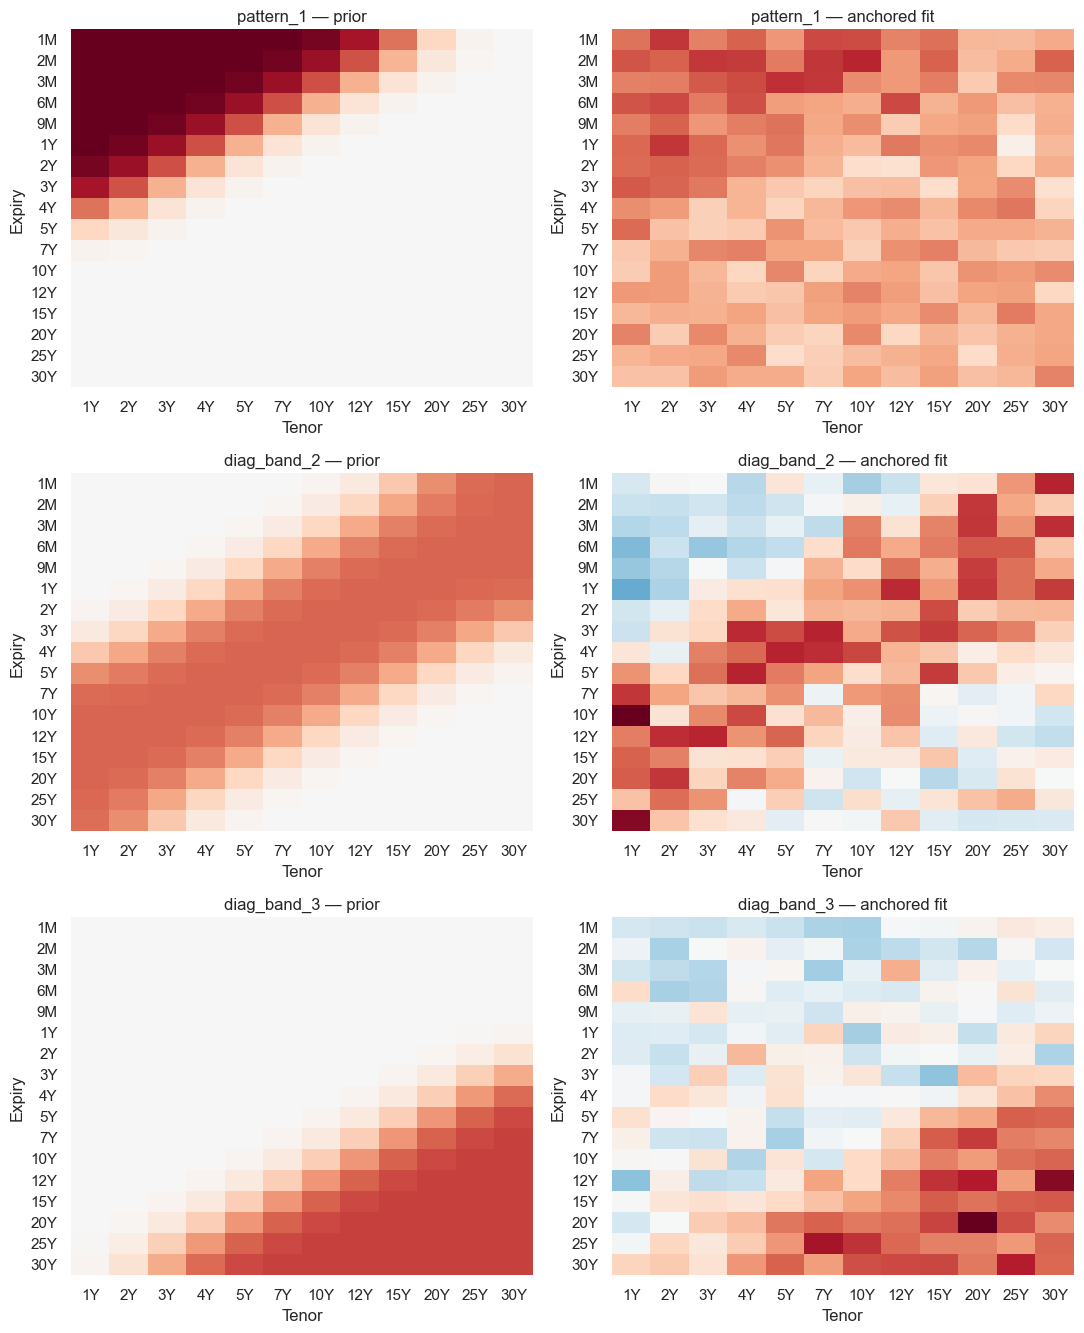

In [ ]:
# Side-by-side: each saved prior next to its anchored fit, on a shared
# colour scale per pattern. Sanity-check that the fit drifts toward
# market structure but stays recognisably the prior.
if priors_path.exists():
    n_p = len(saved_priors)
    fig, axes = plt.subplots(n_p, 2, figsize=(11, 4.5 * n_p),
                             squeeze=False)
    for j, name in enumerate(saved_priors.index):
        p = saved_priors.loc[name].values
        p_norm = p / (np.linalg.norm(p) or 1.0)
        w = l_saved.loc[name].values
        vmax = max(float(np.abs(p_norm).max()), float(np.abs(w).max()), 1e-9)
        loading_heatmap(axes[j, 0], p_norm, f"{name} — prior",        vmax)
        loading_heatmap(axes[j, 1], w,      f"{name} — anchored fit", vmax)
    plt.tight_layout(); plt.show()

## 6. Joint ALS — `soft_constrained_pca`

`sparse_pca_warm` does sequential power iteration (fit one factor,
deflate, fit the next), with unit-norm loadings. `soft_constrained_pca`
is the joint version: minimise

$$\min_{V,\,F}\;\|X - F V^T\|_F^2 \;+\; \sum_j \lambda_j \|v_j - v_j^{(0)}\|^2$$

via alternating least squares, fitting all $k$ factors simultaneously.
Loadings aren't unit-norm; the scores absorb the scale. The penalty
drives $V$ toward the prior; $\lambda \to 0$ recovers ordinary PCA (up
to rotation), $\lambda \to \infty$ freezes $V$ at $V_0$.

Below: two corner-case smoke tests, then a fit on the saved priors
with diagnostics, then a `lambda_search` Pareto sweep.

In [ ]:
# Smoke tests — the two corner cases the spec calls out.
from sklearn.preprocessing import StandardScaler

if priors_path.exists():
    k = len(saved_priors)

    # (a) lam = 0, init = 'pca' should match the top-k PCA subspace.
    fit0 = soft_constrained_pca(rate, saved_priors, lam=0.0, init="pca",
                                max_iter=300, tol=1e-9)
    V0_fit = fit0["V"].values.T                       # (N, k)
    Xs = StandardScaler().fit_transform(rate.values)
    _, _, Vt = np.linalg.svd(Xs, full_matrices=False)
    V_pca = Vt[:k].T
    Q1, _ = np.linalg.qr(V0_fit)
    Q2, _ = np.linalg.qr(V_pca)
    cosines = np.linalg.svd(Q1.T @ Q2, compute_uv=False)
    print(f"lam=0, init='pca'  | principal-angle cosines = {cosines.round(4)}")
    print(f"                    min cosine = {cosines.min():.6f}  "
          f"(1.0 means subspace matches PCA exactly)")

    # (b) lam = 1e8 should freeze V at V0.
    fit_inf = soft_constrained_pca(rate, saved_priors, lam=1e8, init="prior",
                                   max_iter=200, tol=1e-12)
    V_inf = fit_inf["V"].values.T
    V0_arr = saved_priors.values.T
    print(f"\nlam=1e8            | ||V - V0||_F = "
          f"{np.linalg.norm(V_inf - V0_arr):.2e}  (≈ 0 means frozen)")

lam=0, init='pca'  | principal-angle cosines = [1. 1. 1.]
                    min cosine = 1.000000  (1.0 means subspace matches PCA exactly)

lam=1e8            | ||V - V0||_F = 1.30e-06  (≈ 0 means frozen)


per-factor diagnostics (lam=2.0):
    pattern  ||v - v0||  cos(v, v0)  score_var
  pattern_1      5.3887      0.4886     0.9113
diag_band_2      6.2714      0.7475     0.4696
diag_band_3      5.8308      0.5308     1.0026

total reconstruction_error = 94855.10
total loading_deviation   = 102.37
objective_history: 96402.97 → 95059.85 (200 iters)


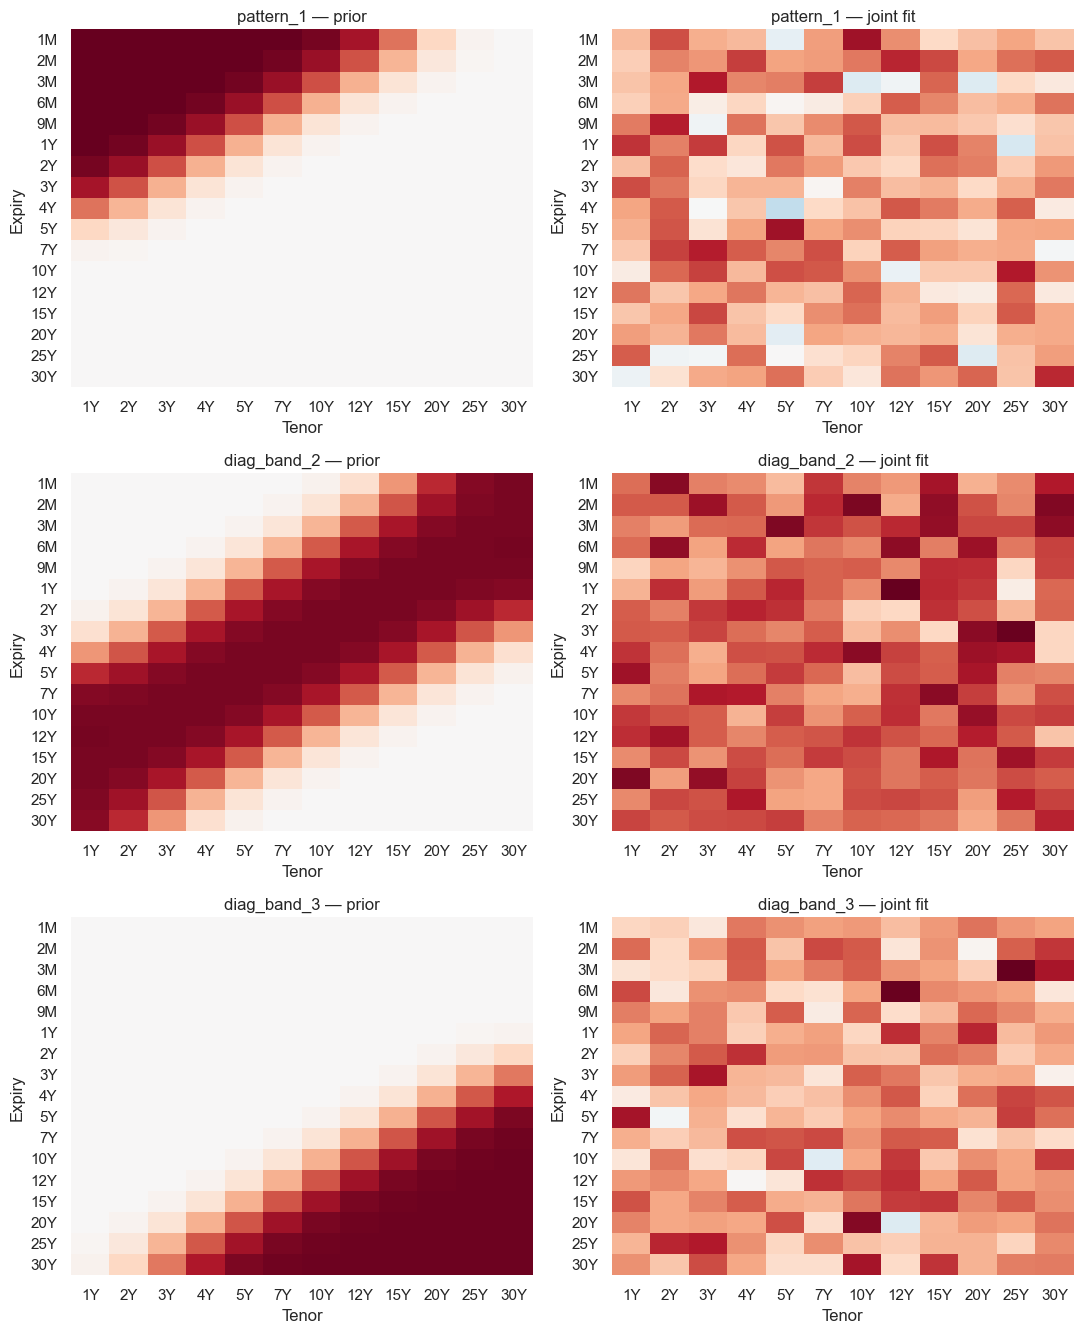

In [ ]:
# Fit on the saved priors at a moderate lambda, inspect diagnostics.
if priors_path.exists():
    fit = soft_constrained_pca(rate, saved_priors, lam=2.0, init="prior",
                               max_iter=200, tol=1e-7)

    rows = []
    for name in saved_priors.index:
        v = fit["V"].loc[name].values
        v0 = saved_priors.loc[name].values
        v0n = v0 / (np.linalg.norm(v0) or 1.0)
        vn  = v  / (np.linalg.norm(v)  or 1.0)
        rows.append({
            "pattern":         name,
            "||v - v0||":      float(np.linalg.norm(v - v0)),
            "cos(v, v0)":      float(vn @ v0n),
            "score_var":       float(fit["F"][name].var()),
        })
    print("per-factor diagnostics (lam=2.0):")
    print(pd.DataFrame(rows).round(4).to_string(index=False))
    print(f"\ntotal reconstruction_error = {fit['reconstruction_error']:.2f}")
    print(f"total loading_deviation   = {fit['loading_deviation']:.2f}")
    print(f"objective_history: {fit['objective_history'][0]:.2f} → "
          f"{fit['objective_history'][-1]:.2f} "
          f"({len(fit['objective_history'])} iters)")

    # Side-by-side prior vs fitted loadings (unit-normed for visual fairness).
    n_p = len(saved_priors)
    fig, axes = plt.subplots(n_p, 2, figsize=(11, 4.5 * n_p), squeeze=False)
    for j, name in enumerate(saved_priors.index):
        v = fit["V"].loc[name].values
        v0 = saved_priors.loc[name].values
        v_n  = v  / (np.linalg.norm(v)  or 1.0)
        v0_n = v0 / (np.linalg.norm(v0) or 1.0)
        vmax = max(float(np.abs(v_n).max()), float(np.abs(v0_n).max()), 1e-9)
        loading_heatmap(axes[j, 0], v0_n, f"{name} — prior",     vmax)
        loading_heatmap(axes[j, 1], v_n,  f"{name} — joint fit", vmax)
    plt.tight_layout(); plt.show()

 lambda  val_reconstruction_error  loading_deviation
    0.0                  19664.77             300.02
    0.1                  19664.61             146.69
    0.5                  19663.78             112.10
    1.0                  19662.79             106.41
    2.0                  19660.98             102.90
    5.0                  19657.14              98.70
   10.0                  19660.31              88.99
   50.0                  19650.83               3.69
  100.0                  19643.65               1.05
 1000.0                  19639.75               0.01


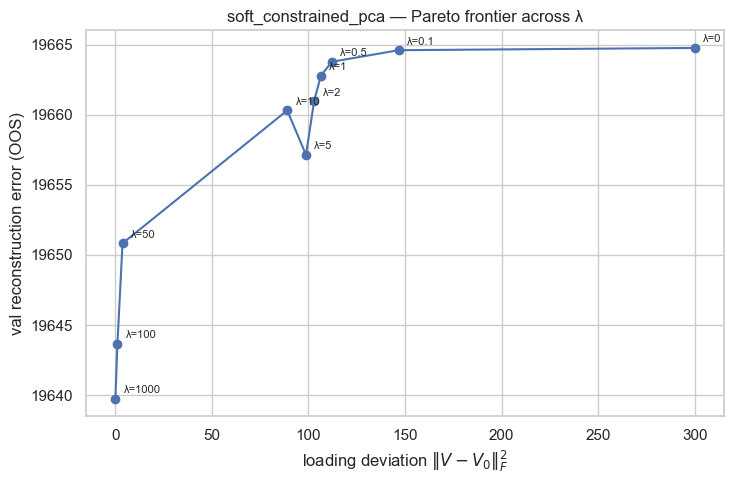

In [ ]:
# Lambda sweep — Pareto frontier from a chronological train/val split.
# Read it as: lower-right is "stay close to prior", upper-left is "fit train hard".
# Pick a knee point by eye — the helper does not auto-select.
if priors_path.exists():
    sweep = lambda_search(
        rate, saved_priors,
        lambda_grid=[0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0, 1000.0],
        val_frac=0.2,
    )
    print(sweep.round(2).to_string(index=False))

    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.plot(sweep["loading_deviation"], sweep["val_reconstruction_error"],
            marker="o")
    for _, r in sweep.iterrows():
        ax.annotate(f"λ={r['lambda']:g}",
                    (r["loading_deviation"], r["val_reconstruction_error"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)
    ax.set_xlabel(r"loading deviation $\|V - V_0\|_F^2$")
    ax.set_ylabel("val reconstruction error (OOS)")
    ax.set_title("soft_constrained_pca — Pareto frontier across λ")
    plt.tight_layout(); plt.show()

## Notes

* Sections 1–5 use `sparse_pca_warm` — sequential power iteration with
  deflation, unit-norm loadings. Build priors in `pattern_creator.py`,
  load them in Section 5.
* Section 6 uses `soft_constrained_pca` — joint ALS matrix
  factorisation with a Tikhonov anchor. Same priors, different
  algorithm. `lambda_search` produces the Pareto frontier on a
  train/val split so you can pick λ by eye.
* `anchor` (sparse PCA) and `lam` (soft-constrained PCA) play similar
  roles but aren't directly comparable — `anchor` is N-scaled to a
  unit knob, `lam` is the raw Tikhonov weight in the ALS objective.